# Run algorithm on COVID data

CovSpectrum is used to get current Covid variants in a timeframe between 14.10.24 to 16.04.25.

As a first try they are grouped by nextstrain clade. The recombinant variants are filtered out by now, because they are not expected to have the standard exponential growth behavior.

In [1]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
import plotly.colors

from viral_variant_comp.plotting import plot_viral_composition_dual, plot_heatmap, plot_viral_composition_interactive
from viral_variant_comp.estimate import calculate_cooccurence
from viral_variant_comp.simulate_count_data import preprocess_covid_data
from viral_variant_comp.estimate import BFGSCompositionEstimator, StepwiseBFGSCompositionEstimator, EvofrCompositionEstimator

/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


url_switzerland = "https://lapis.cov-spectrum.org/gisaid/v2/sample/aggregated?country=Switzerland&dateFrom=2024-10-14&dateTo=2025-04-09&host=Human&accessKey=9Cb3CqmrFnVjO3XCxQLO6gUnKPd&fields=nextcladePangoLineage,date"
url_world = "https://lapis.cov-spectrum.org/gisaid/v2/sample/aggregated?&dateFrom=2024-10-14&dateTo=2025-04-09&host=Human&accessKey=9Cb3CqmrFnVjO3XCxQLO6gUnKPd&fields=nextcladePangoLineage,date,country"
url_usa = "https://lapis.cov-spectrum.org/gisaid/v2/sample/aggregated?country=USA&dateFrom=2024-01-01&dateTo=2025-04-16&host=Human&accessKey=9Cb3CqmrFnVjO3XCxQLO6gUnKPd&fields=nextcladePangoLineage,date,nextstrainClade"
response = requests.get(url_usa)

response.raise_for_status() # Raise an error if the request failed
data = response.json()  # Parse the JSON content
counts_df = pd.DataFrame(data['data'])
counts_df.to_csv("data/counts_covid_usa.csv", index=False)

counts_df.head()

In [2]:
counts_df = pd.read_csv("data/counts_covid_usa.csv")
counts_df.head()

,count,date,nextcladePangoLineage,nextstrainClade
0,2,2024-01-12,HK.20.1,23F
1,1,2024-01-25,HK.13,23F
2,2,2024-01-07,JR.1.1,23F
3,1,2024-01-18,EG.5.1.16,23F
4,1,2024-01-02,DV.7.1.4,23C


In [3]:
data = preprocess_covid_data(counts_df)

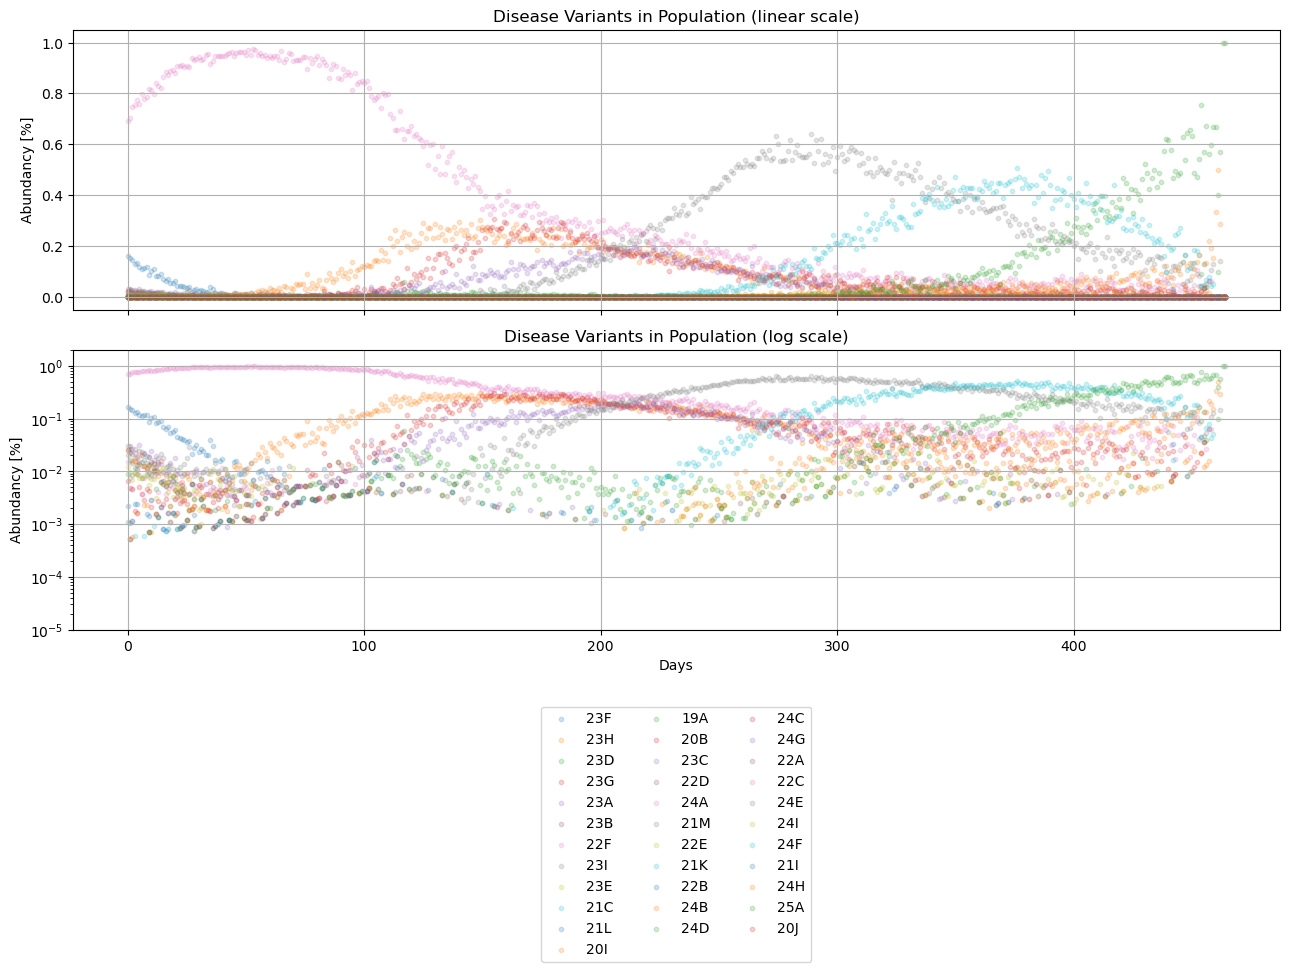

In [4]:
plot_viral_composition_dual(data['counts'], var_names=data['variant_names'], y_range = (1e-5, 2))
plot_viral_composition_interactive(data['counts'], var_names=data['variant_names'], logscale = False)

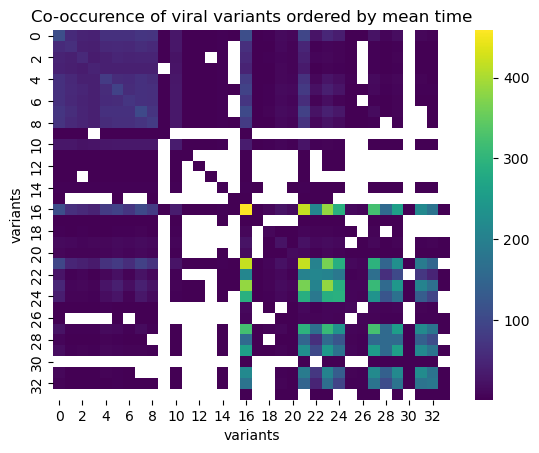

In [5]:
co_occurence_reorderd = calculate_cooccurence(data['counts'])
plot_heatmap(co_occurence_reorderd, "Co-occurence of viral variants ordered by mean time", "variants", "variants")


⏳ Running estimator: BFGS


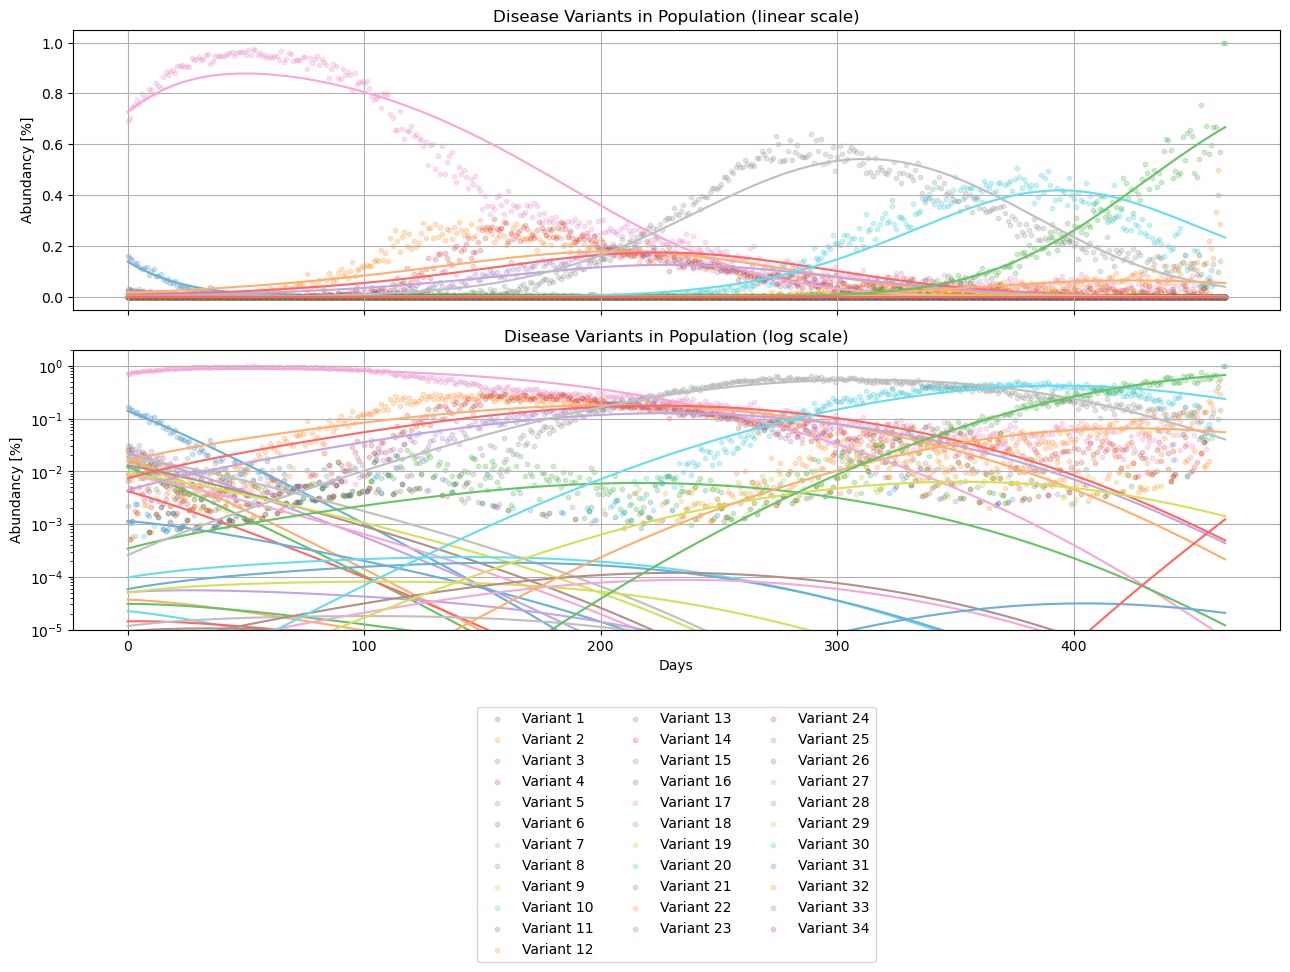


⏳ Running estimator: StepwiseBFGS


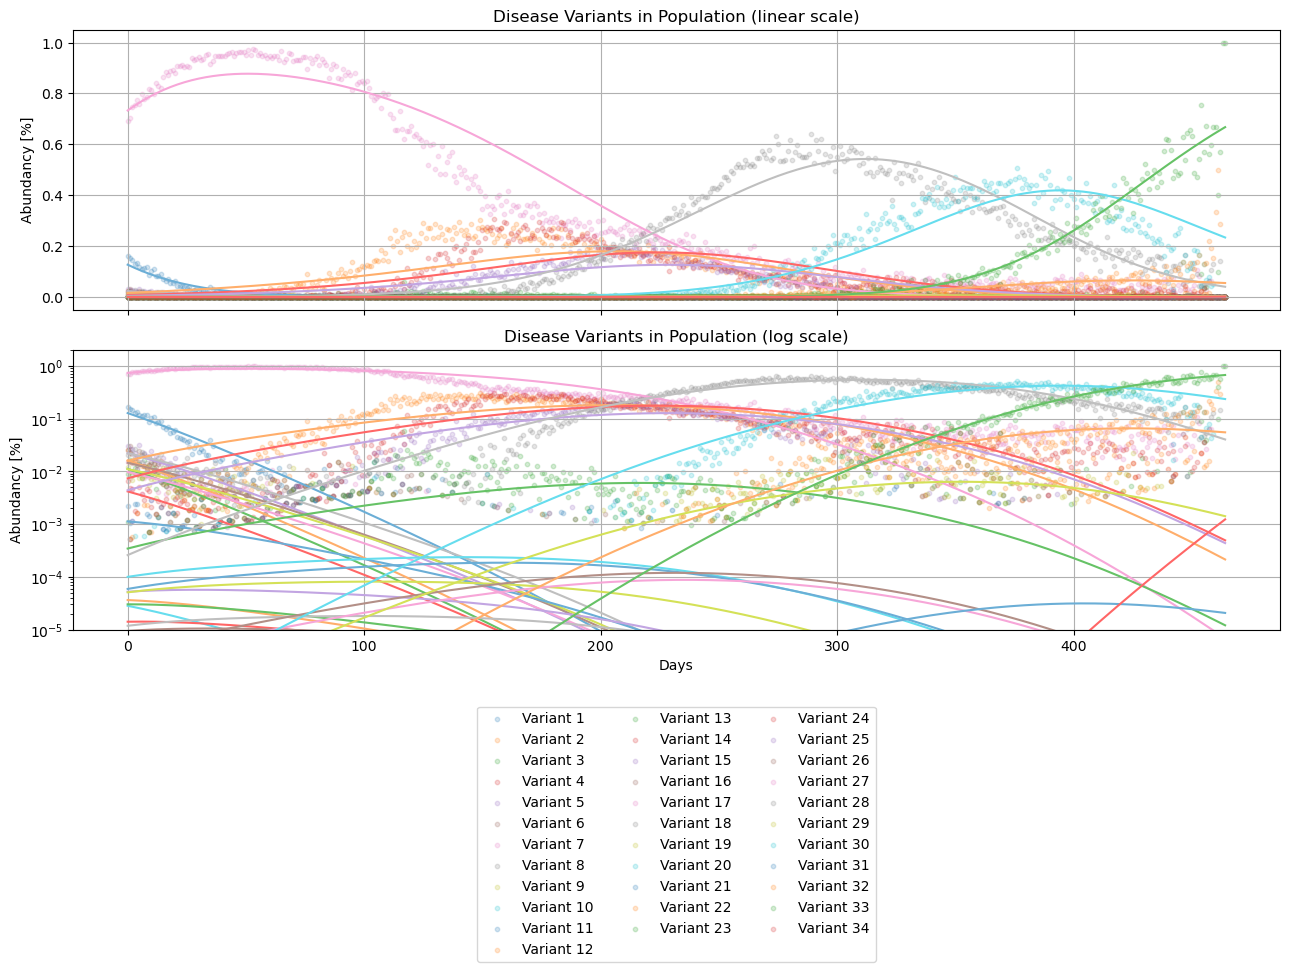


⏳ Running estimator: Evofr


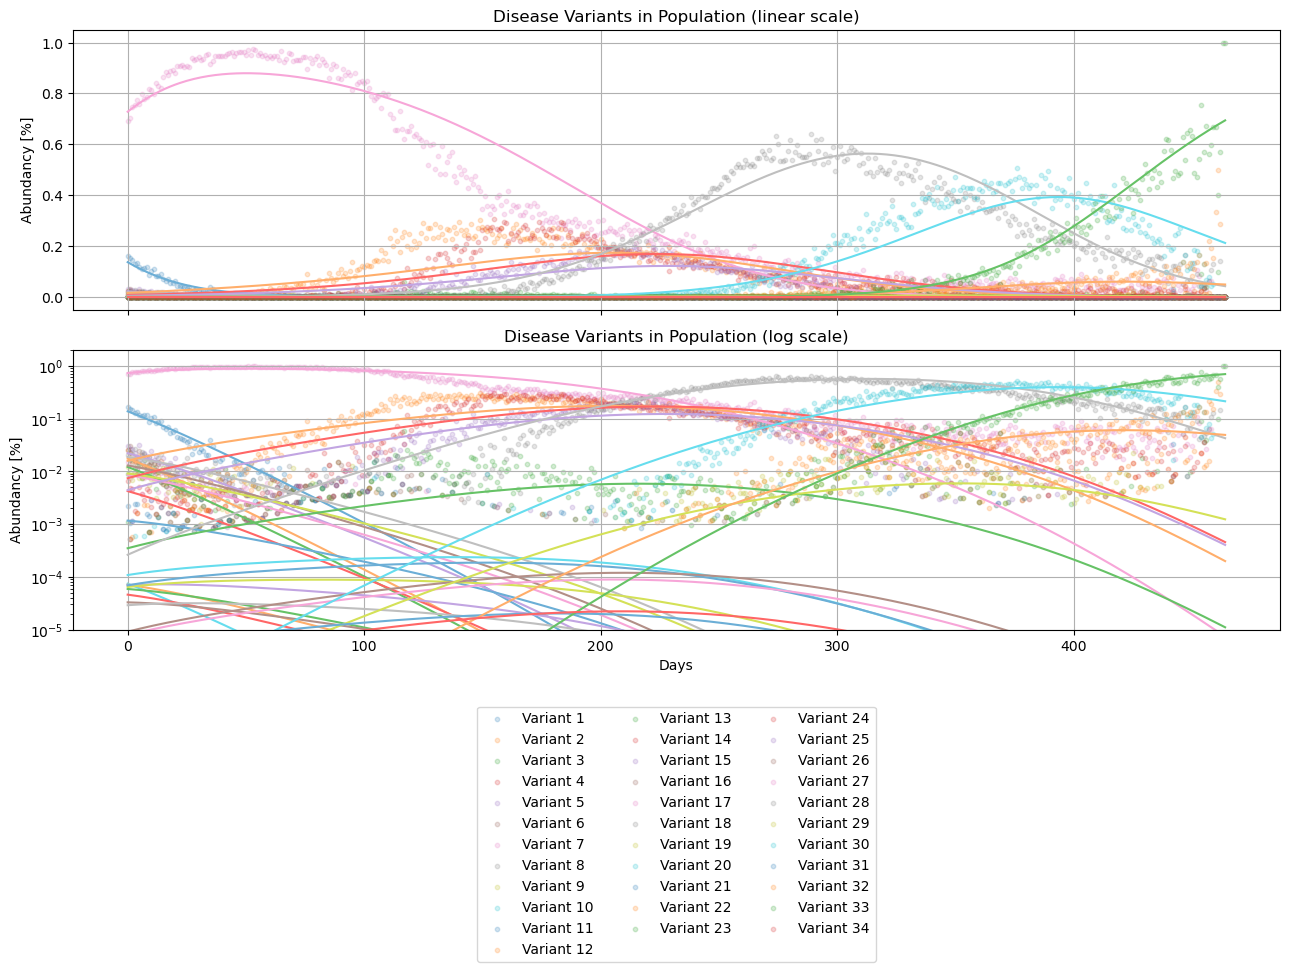

In [6]:
estimators = {
    "BFGS": BFGSCompositionEstimator(data['counts']),
    "StepwiseBFGS": StepwiseBFGSCompositionEstimator(data['counts'], partition_size=9, overlap_size=4),
    "Evofr": EvofrCompositionEstimator(data['counts'], iterations=1000000, learning_rate=4e-3)
}

results = {}

for name, est in estimators.items():
    print(f"\n⏳ Running estimator: {name}")
    est.fit()
    results[name] = est.get_results()

    plot_viral_composition_interactive(data['counts'],composition_estimate=results[name]['composition_estimate'], var_names=data['variant_names'], logscale = False)
    plot_viral_composition_dual(data['counts'], composition_estimate=results[name]['composition_estimate'], y_range = (1e-5, 2))

In [7]:
#counts_df = counts_df[counts_df.date < '2025-03-15']    # counts after this date have counts below 40

#possibly filter out variants with too less counts
#variant_counts = counts_df['nextcladePangoLineage'].value_counts()
#variants_to_keep = variant_counts[variant_counts >= 2].index
#counts_df = counts_df[counts_df['nextcladePangoLineage'].isin(variants_to_keep)]
